# Import Library

In [1]:
import emoji
import pandas as pd
import re
import ast
import numpy as np

# Import Dataset

In [2]:
df = pd.read_csv("data_with_true_label_fixed.csv", delimiter=';', encoding='utf-8-sig')
df

,post_shortcode,post_date,commenter_username,comment_text,comment_likes,true_aspect_1,true_aspect_2,true_sentiment,type
0,DFKccJJPeW_,23/01/2025 09:32,tiara_180319,Pemasangan baru tidak ada kelanjutan setelah s...,0,Pemasangan,Pelayanan,Negatif,Pernyataan
1,DFKccJJPeW_,23/01/2025 09:32,dshellysss,Sama naik semua ini juga komplen..biasanya cum...,0,Harga,Harga,Negatif,Pernyataan
2,DFKccJJPeW_,23/01/2025 09:32,shicya_cute,Min kalau puteran PDAM dol itu sya ngadu kesia...,0,Meteran (Macet/Bermasalah),Meteran (Macet/Bermasalah),Netral,Pertanyaan
3,DFKccJJPeW_,23/01/2025 09:32,iirmawulan,Denda PDAM telat ngalah2in pinjol 50k jadi 150...,1,Harga,Harga,Negatif,Pernyataan
4,DFKccJJPeW_,23/01/2025 09:32,aini_al_aydrus,Air ya klo pagi dan jam 3 sore kenapa selalu mati,1,Air Tidak Mengalir,Air Tidak Mengalir,Negatif,Pertanyaan
...,...,...,...,...,...,...,...,...,...
743,DGe2WlxPbvn,25/02/2025 04:15,mell0dz,gunung anyar tambak apa juga terdampak yaa kok...,1,Air Tidak Mengalir,Air Tidak Mengalir,Netral,Pertanyaan
744,DGe2WlxPbvn,25/02/2025 04:15,dodo_hd12,"Hasilnya gimana, min @pdamsuryasembada ??",1,Lainnya,Lainnya,Netral,Pertanyaan
745,DGcY2FIPTcc,24/02/2025 05:20,adiguna2022,min. daerah sidodadi ada pipa besar bocor. moh...,1,Kebocoran,Kebocoran,Negatif,Pernyataan
746,DGZ7MuDvXk3,23/02/2025 06:22,nikelu22,Min. Ini pdam saya mati sekitar tgl segini. Sa...,0,Air Tidak Mengalir,Pelayanan,Netral,Pertanyaan


# Removing Duplicates

In [3]:
df.duplicated().sum()

np.int64(2)

In [4]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)
df.duplicated().sum()

np.int64(0)

# Preparing Emoji Dataset

In [5]:
df_emoji = pd.read_csv('emoji.csv', index_col=0)

In [6]:
# Ganti spasi dengan underscore pada kolom 'name'
df_emoji['name'] = df_emoji['name'].str.replace(' ', '_')
df_emoji['name'] = df_emoji['name'].str.replace('-', '_')
df_emoji['name'] = df_emoji['name'].str.replace('⊛_', '')
df_emoji['name'] = df_emoji['name'].str.replace('"', '')
df_emoji['name'] = df_emoji['name'].str.replace(':', '')
df_emoji['name'] = df_emoji['name'].str.replace(',', '')
df_emoji['name'] = df_emoji['name'].str.replace("'", "")
# Tampilkan 5 baris pertama untuk memastikan hasilnya
print(df_emoji.head())

                              name
0                    grinning_face
1      grinning_face_with_big_eyes
2  grinning_face_with_smiling_eyes
3   beaming_face_with_smiling_eyes
4          grinning_squinting_face


In [7]:
df_emoji.to_csv('emoji_underscore.csv', index=True)

In [8]:
df_emoji

,name
0,grinning_face
1,grinning_face_with_big_eyes
2,grinning_face_with_smiling_eyes
3,beaming_face_with_smiling_eyes
4,grinning_squinting_face
...,...
1811,flag_Zambia
1812,flag_Zimbabwe
1813,flag_England
1814,flag_Scotland


# Cleansing

In [9]:
# --- 1. Baca daftar emoji dari file emoji_underscore.csv ---
emoji_df = pd.read_csv('emoji_underscore.csv')
emoji_df['name'] = emoji_df['name'].astype(str).str.strip()

# Buat pola regex berdasarkan nama emoji (format :emoji_name:)
emoji_names = [re.escape(name) for name in emoji_df['name'] if name]
emoji_pattern = re.compile(r':(' + '|'.join(emoji_names) + r'):', flags=re.IGNORECASE)


# --- 2. Fungsi pembersihan teks ---
def clean_text(text):
    if pd.isna(text):
        return ''
    
    text = str(text).lower()

    # Hapus emoji berdasarkan daftar emoji
    text = emoji_pattern.sub('', text)

    # Hapus URL
    text = re.sub(r'http\S+|www.\S+', '', text)
    
    # Hapus tanda hubung "-"
    text = re.sub('-', ' ', text)
    
    # Hapus mention dan hashtag
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Hapus angka dan simbol non-huruf
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# Terapkan fungsi clean_text ke kolom comment_text
df['cleaned_text'] = df['comment_text'].apply(clean_text)

# --- 4. Hapus baris yang kosong atau hanya berisi emoji (setelah dibersihkan jadi kosong) ---
before = len(df)
df = df[df['cleaned_text'].str.strip().astype(bool)]
after = len(df)

print(f"🧹 {before - after} baris dihapus karena hanya berisi emoji atau kosong.")

🧹 55 baris dihapus karena hanya berisi emoji atau kosong.


In [10]:
print(df['cleaned_text'].to_markdown())

|     | cleaned_text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
|----:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Tokenize + Stopword Removal + Formalization

In [11]:
import nltk
import string
from nltk.tokenize import word_tokenize

# Pastikan tokenizer sudah diunduh
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# --- Fungsi Slang Removal + Stopword Filtering + Tokenization ---
def slang_remove_tokenize(text):
    if pd.isna(text) or not isinstance(text, str):
        return []

    # Baca daftar stopwords
    with open("combined_stop_words.txt", "r", encoding="utf-8") as f:
        stop_words = f.read().splitlines()

    # Baca daftar slang words
    with open("update_combined_slang_words.txt", "r", encoding="utf-8") as f:
        slang_words = ast.literal_eval(f.read())

    # Tokenisasi teks
    word_tokens = word_tokenize(text.lower())

    # Ganti slang dengan padanan katanya
    normalized_tokens = [slang_words.get(w, w) for w in word_tokens]

    # Filter stopword dan tanda baca
    filtered_tokens = [
        w for w in normalized_tokens 
        if w not in stop_words and w not in string.punctuation and w.strip()
    ]

    return filtered_tokens  # bisa juga ' '.join(filtered_tokens) jika ingin string

df['tokens'] = df['cleaned_text'].apply(slang_remove_tokenize)

print(df[['cleaned_text', 'tokens']].to_markdown())

|     | cleaned_text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            | tokens                                                                                                                                                                                                                

# Drop Empty row

In [12]:
# --- 2️⃣ Jika kolom tokens disimpan dalam bentuk string list (contoh: "['air', 'keruh']") ---
# Ubah string list menjadi list Python sesungguhnya
def safe_eval(x):
    try:
        if isinstance(x, str) and x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        elif isinstance(x, float) and pd.isna(x):
            return []
        else:
            return x
    except:
        return []

df['tokens'] = df['tokens'].apply(safe_eval)

# --- 3️⃣ Hapus baris dengan kolom tokens kosong ---
before = len(df)
df = df[df['tokens'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
after = len(df)

print(f"✅ Baris kosong pada kolom 'tokens' berhasil dihapus.")
print(f"🗑️ Total baris dihapus: {before - after}")
# df.to_csv("cleaned_tokens_dataset.csv", sep = ';', index=False, encoding='utf-8-sig')


✅ Baris kosong pada kolom 'tokens' berhasil dihapus.
🗑️ Total baris dihapus: 12


# Stemming

In [13]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()
df['final_data'] = df['tokens'].apply(lambda x: stemmer.stem(" ".join(x)) if isinstance(x, list) else stemmer.stem(x))
print(df['final_data'].to_markdown())
df[['post_shortcode', 'comment_text', 'cleaned_text', 'tokens', 'final_data']].to_csv("final_stemmed_dataset.csv", index=False, encoding='utf-8-sig')

|     | final_data                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
|----:|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Split Data : 80% Train + 20% Test

In [14]:
from sklearn.model_selection import train_test_split
#--- Menggunakan aspek Lainnya ---
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    # stratify=df['true_aspect_1']
)
# test_df = test_df.drop(columns=['true_aspect_1', 'comment_likes', 'true_aspect_2', 'true_sentiment', 'type'])

test_df.to_csv("test_data_aspek_lainnya.csv", index=False, encoding='utf-8-sig')
train_df.to_csv("train_data_aspek_lainnya.csv", index=False, encoding='utf-8-sig')

# --- IGNORE Lainnya Aspect ---
df_non_lainnya = df[df['true_aspect_1'] != 'Lainnya'].copy()
train_df_non_lainnya, test_df_non_lainnya = train_test_split(
    df_non_lainnya,
    test_size=0.2,                            # 20% data uji
    random_state=42,
    shuffle=True,
    # stratify=df_non_lainnya['true_aspect_1']  # stratify hanya aspek inti
)
# test_df_non_lainnya = test_df.drop(columns=['true_aspect_1', 'comment_likes', 'true_aspect_2', 'true_sentiment', 'type'])

# Dengan Aspek "Lainnya"

## Feature Extraction & Aspect Based Classification

In [15]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2
)

X_train = vectorizer.fit_transform(train_df['final_data'])
X_test  = vectorizer.transform(test_df['final_data'])

cosine_sim = cosine_similarity(X_test, X_train)

THRESHOLD = 0.3  # bisa dituning

predicted_aspects = []
similarity_scores = []

for i in range(cosine_sim.shape[0]):
    row = cosine_sim[i]
    best_idx = row.argmax()
    best_score = row[best_idx]
    best_aspect = train_df.iloc[best_idx]['true_aspect_1']
    print(f"baris{i}: {row}")
    print(f"baris{i}: {best_idx}")
    print(f"Baris {i}: Best Aspect = {best_aspect}, Score = {best_score}")  # Debugging line
    if best_score < THRESHOLD:
        predicted_aspects.append("Lainnya")
    else:
        predicted_aspects.append(best_aspect)

    similarity_scores.append(best_score)

test_df['predicted_aspect'] = predicted_aspects
test_df['similarity_score'] = similarity_scores

test_df.to_csv(
    "aspect_classification_cosine_similarity.csv",
    index=False
)

print("✅ Aspect-based classification selesai!")
print(test_df[['comment_text', 'predicted_aspect', 'similarity_score']].head())

baris0: [0.02727104 0.02133265 0.         0.         0.         0.
 0.         0.         0.08484131 0.         0.14155225 0.02780368
 0.         0.02807386 0.         0.         0.04175688 0.
 0.12759164 0.0595425  0.         0.01802255 0.05855262 0.10100157
 0.03732821 0.         0.         0.0149102  0.         0.02583425
 0.         0.20515585 0.         0.         0.         0.11991793
 0.         0.01802464 0.         0.         0.06627108 0.0169083
 0.08846993 0.08319093 0.         0.01704415 0.         0.
 0.02716513 0.07419258 0.         0.01651099 0.01555484 0.
 0.05129738 0.07710739 0.15731186 0.         0.         0.01811364
 0.02238184 0.02939372 0.12372248 0.11326294 0.02232019 0.
 0.         0.         0.         0.         0.0825507  0.
 0.04096473 0.12941664 0.         0.14075638 0.         0.
 0.02032976 0.         0.01646683 0.         0.         0.0958569
 0.04547748 0.02512728 0.09356195 0.01918419 0.         0.
 0.03531988 0.19872573 0.0288978  0.09439974 0.      

# Aspect Based Evaluation

Total Data Train : 543
Total Data Test  : 136

🎯 Accuracy: 0.6544

📊 Classification Report:

                            precision    recall  f1-score   support

             Air Kotor/Bau     0.5714    0.5714    0.5714         7
        Air Tidak Mengalir     0.7949    0.7209    0.7561        43
                     Harga     0.5385    0.5000    0.5185        14
                 Kebocoran     0.3333    0.5000    0.4000         2
                   Lainnya     0.7347    0.7500    0.7423        48
Meteran (Macet/Bermasalah)     0.6364    0.5385    0.5833        13
                 Pelayanan     0.2000    0.2857    0.2353         7
                Pemasangan     0.2500    0.5000    0.3333         2

                  accuracy                         0.6544       136
                 macro avg     0.5074    0.5458    0.5175       136
              weighted avg     0.6752    0.6544    0.6625       136



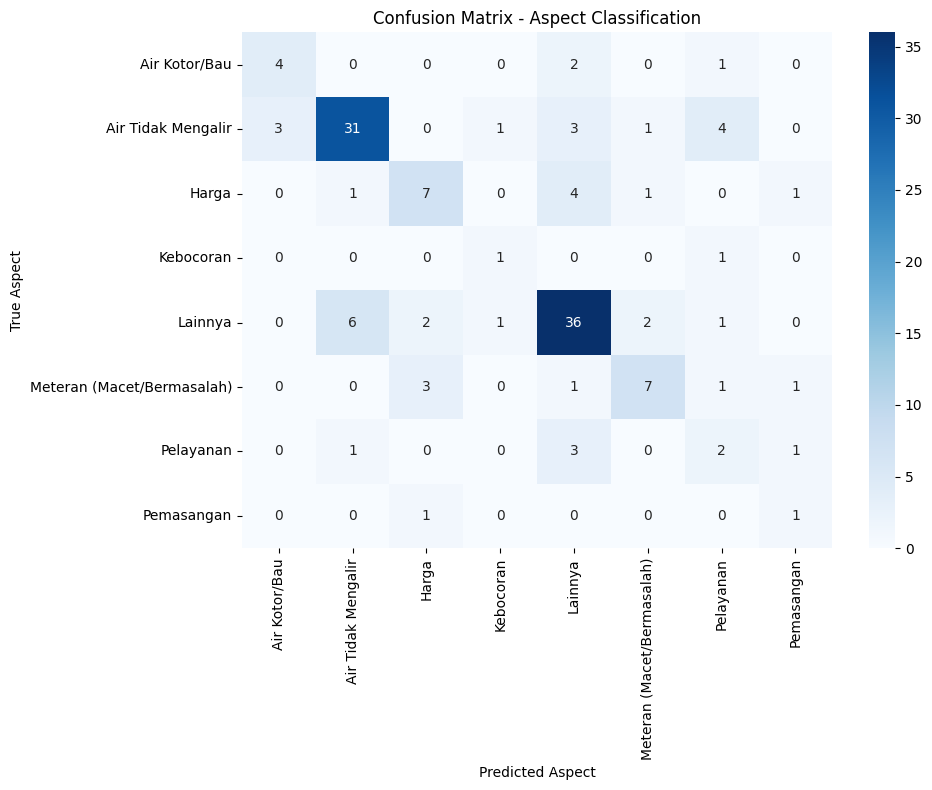


📊 Statistik Predicted Aspect (Test Data)
| predicted_aspect           |   Jumlah_Kemunculan |   Rata_rata_Similarity |
|:---------------------------|--------------------:|-----------------------:|
| Lainnya                    |                  49 |               0.555437 |
| Air Tidak Mengalir         |                  39 |               0.541988 |
| Harga                      |                  13 |               0.559374 |
| Meteran (Macet/Bermasalah) |                  11 |               0.544437 |
| Pelayanan                  |                  10 |               0.544062 |
| Air Kotor/Bau              |                   7 |               0.478808 |
| Pemasangan                 |                   4 |               0.415339 |
| Kebocoran                  |                   3 |               0.445915 |

📌 Jumlah Tiap Aspek (True Label - Test Data)
| Aspek                      |   Jumlah |
|:---------------------------|---------:|
| Lainnya                    |       48 |
| Air 

In [16]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================
# 1️⃣ EVALUASI DASAR
# =========================================================

y_true = test_df['true_aspect_1']
y_pred = test_df['predicted_aspect']

print(f"Total Data Train : {len(train_df)}")
print(f"Total Data Test  : {len(test_df)}")

accuracy = accuracy_score(y_true, y_pred)
print(f"\n🎯 Accuracy: {accuracy:.4f}")

print("\n📊 Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    digits=4
))

# =========================================================
# 2️⃣ CONFUSION MATRIX
# =========================================================

labels = sorted(y_true.unique())

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted Aspect")
plt.ylabel("True Aspect")
plt.title("Confusion Matrix - Aspect Classification")
plt.tight_layout()
plt.show()

# =========================================================
# 3️⃣ STATISTIK PREDICTED ASPECT
#    (Jumlah & Rata-rata Similarity)
# =========================================================

aspect_stats = (
    test_df
    .groupby('predicted_aspect')
    .agg(
        Jumlah_Kemunculan=('predicted_aspect', 'count'),
        Rata_rata_Similarity=('similarity_score', 'mean')
    )
    .reset_index()
    .sort_values('Jumlah_Kemunculan', ascending=False)
)

print("\n===========================================")
print("📊 Statistik Predicted Aspect (Test Data)")
print("===========================================")
print(aspect_stats.to_markdown(index=False))

# =========================================================
# 4️⃣ DISTRIBUSI TRUE LABEL (TEST DATA)
# =========================================================

true_aspect_stats = (
    test_df['true_aspect_1']
    .value_counts()
    .reset_index()
)
true_aspect_stats.columns = ['Aspek', 'Jumlah']

print("\n==================================================")
print("📌 Jumlah Tiap Aspek (True Label - Test Data)")
print("==================================================")
print(true_aspect_stats.to_markdown(index=False))

# =========================================================
# 5️⃣ TOTAL PREDIKSI BENAR & SALAH
# =========================================================

misclassified_mask = y_true != y_pred

total_misclassified = misclassified_mask.sum()
total_correct = (~misclassified_mask).sum()

print("\n===========================================")
print("❌ HASIL KLASIFIKASI")
print("===========================================")
print(f"Total Data Test           : {len(test_df)}")
print(f"Total Prediksi Benar      : {total_correct}")
print(f"Total Prediksi Salah      : {total_misclassified}")
print(f"Persentase Salah Prediksi : {total_misclassified/len(test_df)*100:.2f}%")

# =========================================================
# 6️⃣ DETAIL DATA SALAH PREDIKSI (OPSIONAL TAPI PENTING)
# =========================================================

misclassified_df = test_df.loc[
    misclassified_mask,
    ['final_data', 'true_aspect_1', 'predicted_aspect', 'similarity_score']
]

# Simpan untuk analisis lanjutan (opsional)
misclassified_df.to_csv(
    "misclassified_aspect_data.csv",
    index=False,
    encoding='utf-8-sig'
)


# Tanpa Aspek "Lainnya"

## Feature Extraction & Aspect Based Classification

In [17]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# =========================================================
# 1️⃣ FILTER DATA (HILANGKAN ASPEK "LAINNYA")
# =========================================================

train_df_non_lainnya = train_df[train_df['true_aspect_1'] != 'Lainnya'].reset_index(drop=True)
test_df_non_lainnya  = test_df[test_df['true_aspect_1'] != 'Lainnya'].reset_index(drop=True)

# =========================================================
# 2️⃣ TF-IDF VECTORIZATION
# =========================================================

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2
)

X_train_non_lainnya = vectorizer.fit_transform(train_df_non_lainnya['final_data'])
X_test_non_lainnya  = vectorizer.transform(test_df_non_lainnya['final_data'])

# =========================================================
# 3️⃣ COSINE SIMILARITY
# =========================================================

cosine_sim = cosine_similarity(X_test_non_lainnya, X_train_non_lainnya)

# =========================================================
# 4️⃣ ASPECT PREDICTION (TANPA "LAINNYA")
# =========================================================

predicted_aspects = []
similarity_scores = []

for i in range(cosine_sim.shape[0]):
    row = cosine_sim[i]

    best_idx = row.argmax()
    best_score = row[best_idx]
    best_aspect = train_df_non_lainnya.iloc[best_idx]['true_aspect_1']

    predicted_aspects.append(best_aspect)
    similarity_scores.append(best_score)

# =========================================================
# 5️⃣ SIMPAN HASIL
# =========================================================

test_df_non_lainnya['predicted_aspect'] = predicted_aspects
test_df_non_lainnya['similarity_score'] = similarity_scores

test_df_non_lainnya.to_csv(
    "aspect_classification_cosine_similarity_no_lainnya.csv",
    index=False
)

print("✅ Aspect-based classification selesai (tanpa aspek 'Lainnya')!")
print(test_df_non_lainnya[['comment_text', 'predicted_aspect', 'similarity_score']].head())


✅ Aspect-based classification selesai (tanpa aspek 'Lainnya')!
                                        comment_text    predicted_aspect  \
0  Air pdam saya bulan januari msh puluhan dan ka...  Air Tidak Mengalir   
1  Udh bbrp hari ini lho debit air sidosermo pdk ...  Air Tidak Mengalir   
2  Pak air dirmh  saya kluarnya sangat kecil  sek...  Air Tidak Mengalir   
3                        Siwalankerto gak metu blass           Pelayanan   
4  Pertanyaan buat PDAM, saya mau tanyak setiap p...          Pemasangan   

   similarity_score  
0          0.285491  
1          0.401779  
2          0.350169  
3          0.624721  
4          0.332943  


## Aspect Based Result Evaluation

Total Data Train : 355
Total Data Test  : 88

🎯 Accuracy: 0.6705

📊 Classification Report:

                            precision    recall  f1-score   support

             Air Kotor/Bau     0.5000    0.5714    0.5333         7
        Air Tidak Mengalir     0.8250    0.7674    0.7952        43
                     Harga     0.6667    0.5714    0.6154        14
                 Kebocoran     0.5000    0.5000    0.5000         2
Meteran (Macet/Bermasalah)     0.7273    0.6154    0.6667        13
                 Pelayanan     0.4000    0.5714    0.4706         7
                Pemasangan     0.2000    0.5000    0.2857         2

                  accuracy                         0.6705        88
                 macro avg     0.5456    0.5853    0.5524        88
              weighted avg     0.7041    0.6705    0.6827        88



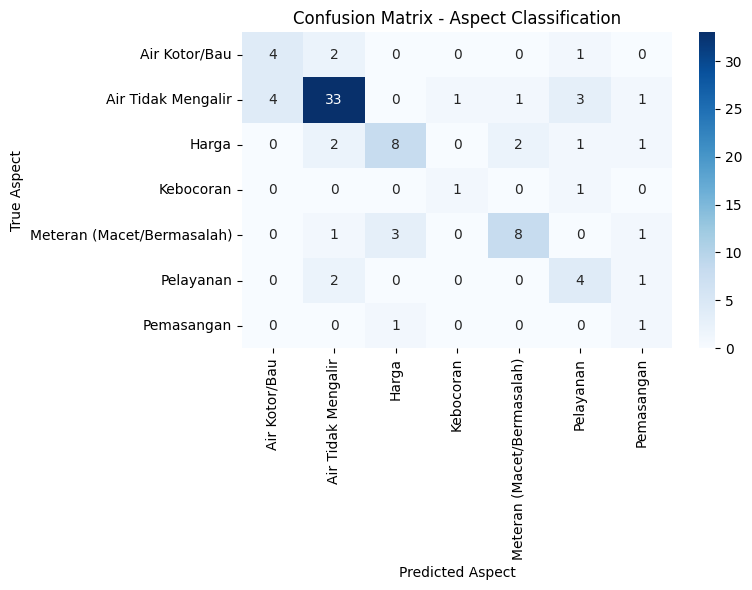


📊 Statistik Predicted Aspect (Test Data)
| predicted_aspect           |   Jumlah_Kemunculan |   Rata_rata_Similarity |
|:---------------------------|--------------------:|-----------------------:|
| Air Tidak Mengalir         |                  40 |               0.504957 |
| Harga                      |                  12 |               0.532244 |
| Meteran (Macet/Bermasalah) |                  11 |               0.52501  |
| Pelayanan                  |                  10 |               0.551406 |
| Air Kotor/Bau              |                   8 |               0.431521 |
| Pemasangan                 |                   5 |               0.416697 |
| Kebocoran                  |                   2 |               0.394777 |

📌 Jumlah Tiap Aspek (True Label - Test Data)
| Aspek                      |   Jumlah |
|:---------------------------|---------:|
| Air Tidak Mengalir         |       43 |
| Harga                      |       14 |
| Meteran (Macet/Bermasalah) |       13 |


In [18]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================
# 1️⃣ EVALUASI DASAR
# =========================================================

y_true_non_lainnya = test_df_non_lainnya['true_aspect_1']
y_pred_non_lainnya = test_df_non_lainnya['predicted_aspect']

print(f"Total Data Train : {len(train_df_non_lainnya)}")
print(f"Total Data Test  : {len(test_df_non_lainnya)}")

accuracy = accuracy_score(y_true_non_lainnya, y_pred_non_lainnya)
print(f"\n🎯 Accuracy: {accuracy:.4f}")

print("\n📊 Classification Report:\n")
print(classification_report(
    y_true_non_lainnya,
    y_pred_non_lainnya,
    digits=4
))

# =========================================================
# 2️⃣ CONFUSION MATRIX
# =========================================================

labels = sorted(y_true_non_lainnya.unique())

cm = confusion_matrix(y_true_non_lainnya, y_pred_non_lainnya, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted Aspect")
plt.ylabel("True Aspect")
plt.title("Confusion Matrix - Aspect Classification")
plt.tight_layout()
plt.show()

# =========================================================
# 3️⃣ STATISTIK PREDICTED ASPECT
#    (Jumlah & Rata-rata Similarity)
# =========================================================

aspect_stats = (
    test_df_non_lainnya
    .groupby('predicted_aspect')
    .agg(
        Jumlah_Kemunculan=('predicted_aspect', 'count'),
        Rata_rata_Similarity=('similarity_score', 'mean')
    )
    .reset_index()
    .sort_values('Jumlah_Kemunculan', ascending=False)
)

print("\n===========================================")
print("📊 Statistik Predicted Aspect (Test Data)")
print("===========================================")
print(aspect_stats.to_markdown(index=False))

# =========================================================
# 4️⃣ DISTRIBUSI TRUE LABEL (TEST DATA)
# =========================================================

true_aspect_stats = (
    test_df_non_lainnya['true_aspect_1']
    .value_counts()
    .reset_index()
)
true_aspect_stats.columns = ['Aspek', 'Jumlah']

print("\n==================================================")
print("📌 Jumlah Tiap Aspek (True Label - Test Data)")
print("==================================================")
print(true_aspect_stats.to_markdown(index=False))

# =========================================================
# 5️⃣ TOTAL PREDIKSI BENAR & SALAH
# =========================================================

misclassified_mask = y_true_non_lainnya != y_pred_non_lainnya

total_misclassified = misclassified_mask.sum()
total_correct = (~misclassified_mask).sum()

print("\n===========================================")
print("❌ HASIL KLASIFIKASI")
print("===========================================")
print(f"Total Data Test           : {len(test_df_non_lainnya)}")
print(f"Total Prediksi Benar      : {total_correct}")
print(f"Total Prediksi Salah      : {total_misclassified}")
print(f"Persentase Salah Prediksi : {total_misclassified/len(test_df_non_lainnya)*100:.2f}%")

# =========================================================
# 6️⃣ DETAIL DATA SALAH PREDIKSI (OPSIONAL TAPI PENTING)
# =========================================================

misclassified_df = test_df_non_lainnya.loc[
    misclassified_mask,
    ['final_data', 'true_aspect_1', 'predicted_aspect', 'similarity_score']
]

# Simpan untuk analisis lanjutan (opsional)
misclassified_df.to_csv(
    "non_lainnya_misclassified_aspect_data.csv",
    index=False,
    encoding='utf-8-sig'
)
